In [1]:
import torch.utils.data as data
import numpy as np
import os
import sys
from PIL import Image
import torch
import random
import math
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import subprocess
from collections import defaultdict

from torch.autograd import Variable
from torchinfo import summary

print(torchvision.__version__)
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.current_device())

data_root_dir = "/scratch1/zeyut/eat_detection/"

0.9.1+cu102
1.9.1+cu102
True
0


In [2]:
class AverageMeter(object):
    """Computes and stores the average and current value"""

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count
        
class GestureCountMatrix():
    def __init__(self,result_loc,gt_loc, downsample_rate, subject_wise=True):
        self.result_loc = result_loc
        self.pred_ges_loc = result_loc + "ges_boundaries/"
        self.pred_loc = result_loc + "frame_preds/"
        self.gt_loc = gt_loc
        self.downsample_rate = downsample_rate
        self.subject_wise = subject_wise
        self.video_list = [f[6:-4] for f in os.listdir(self.pred_loc) if f.startswith("preds")]

        self.subject_list = np.array([str.split(video,"_")[0] for video in self.video_list])
        self.subject_set = sorted(np.unique(self.subject_list),reverse=False)
        
    def CalculateGestureCount(self,write=False,smooth=True,smooth_kernel_params=[1,1,1,1]):
        self.CalculateBoundaries(write=write,smooth=smooth,smooth_kernel_params=smooth_kernel_params)
        
        matrixs = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: 0)))
        for video_idx in self.video_list:
            subject = video_idx
            if self.subject_wise:
                subject = str.split(video_idx,"_")[0]
            f_gt = open(f"{self.gt_loc}{video_idx}/gt_ges_3labels.txt","r")
            gt = []
            bite_average = AverageMeter()
            drink_average = AverageMeter()

            for line in f_gt.readlines():
                info = str.split(str.split(line, "\n")[0], "\t") 
                gt.append([LABEL_TABLE[info[0]],int(info[1]),int(info[2])])
                if info[0] == "bite":
                    bite_average.update(int(info[2])-int(info[1]))
                if info[0] == "drink":
                    drink_average.update(int(info[2])-int(info[1]))
            matrixs[subject][0]["average_len"] = bite_average.avg
            matrixs[subject][1]["average_len"] = drink_average.avg

            self.evaluate_results(gt, self.predictions[video_idx], matrixs[subject])

        summary_matrixs = defaultdict(lambda: defaultdict(lambda: 0))
        if self.subject_wise:
            loop_list = self.subject_set
        else:
            loop_list = self.video_list
        for ges_type in range(2):
            for key in ['tp','fp','missed','confused']:
                for subject in loop_list:
                    summary_matrixs[ges_type][key] += matrixs[subject][ges_type][key]                           
        self.summary_matrixs = summary_matrixs
        self.matrixs = matrixs
        self.tp = [self.summary_matrixs[0]['tp'],self.summary_matrixs[1]['tp']]
        self.fp = [self.summary_matrixs[0]['fp'],self.summary_matrixs[1]['fp']]
        self.missed = [self.summary_matrixs[0]['missed'],self.summary_matrixs[1]['missed']]
        self.confused = [self.summary_matrixs[0]['confused'],self.summary_matrixs[1]['confused']]

        self.precision = [self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+self.summary_matrixs[0]['fp']),
                         self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+self.summary_matrixs[1]['fp'])]
        self.recall = [self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+self.summary_matrixs[0]['missed']),
                        self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+self.summary_matrixs[1]['missed'])]      
        self.f1 = [self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+0.5*(self.summary_matrixs[0]['fp']+self.summary_matrixs[0]['missed'])),
                  self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+0.5*(self.summary_matrixs[1]['fp']+self.summary_matrixs[1]['missed']))]
        
    def CalculateBoundaries(self, write=False,smooth=True,smooth_kernel_params=[1,1,1,1]):
        if write:
            try:
                os.mkdir(f"{self.result_loc}ges_boundaries/")
            except:
                pass
        self.predictions = {}
        for video_idx in self.video_list:
            preds, labels, start_idx = self.read_results(video_idx)
            if smooth:
                processed_preds = self.smooth_results(preds,
                                                      kernel1=smooth_kernel_params[0],
                                                      kernel2=smooth_kernel_params[1],
                                                      kernel3=smooth_kernel_params[2],
                                                      kernel4=smooth_kernel_params[3])
            else:
                processed_preds = preds
            cur_start = -1
            pred_boundaries = []
            pred_types = []
            pre_pred = -1
            for idx, pred in enumerate(processed_preds):
                if pred == pre_pred:
                    continue
                if cur_start == -1 and pred == 2:
                    continue
                if idx != 0 and cur_start != -1:
                    pred_types.append(pre_pred)
                    pred_boundaries.append([cur_start+start_idx,(idx-1)*self.downsample_rate+start_idx])
                    cur_start = -1
                else:
                    cur_start = idx * self.downsample_rate
                pre_pred = pred
            if write:
                f = open(f"{self.result_loc}ges_boundaries/ges_{video_idx}.txt","w")
                f.write("\n".join(["{}\t{}\t{}".\
                        format(ges_type,boundary[0],boundary[1]) \
                        for ges_type,boundary in (zip(pred_types,pred_boundaries))]))
                f.close()
            self.predictions[video_idx] = [[ges_type,boundary[0],boundary[1]] for ges_type,boundary in zip(pred_types,pred_boundaries)]

    def CalculateIndividualMatrix(self):
        average_precision = defaultdict(lambda: 0)
        average_recall = defaultdict(lambda: 0)
        bite_precision = defaultdict(lambda: 0) 
        bite_recall = defaultdict(lambda: 0) 
        
        if self.subject_wise:
            loop_list = self.subject_set
        else:
            loop_list = self.video_list
        for subject in loop_list:
            try:
                self.matrixs[subject][0]['precision'] = self.matrixs[subject][0]['tp']/(self.matrixs[subject][0]['tp']+self.matrixs[subject][0]['fp'])
            except:
                pass
            try:
                self.matrixs[subject][1]['precision'] = self.matrixs[subject][1]['tp']/(self.matrixs[subject][1]['tp']+self.matrixs[subject][1]['fp'])
            except:
                pass
            bite_precision[subject] = self.matrixs[subject][0]['precision']   
            # if there is a precision in "drink"
            if self.matrixs[subject][1]['tp']+self.matrixs[subject][1]['fp'] != 0:
                #average_precision[subject] = matrixs[subject][0]['precision']
                average_precision[subject] = (self.matrixs[subject][0]['precision'] + self.matrixs[subject][1]['precision']) / 2
            else:
                average_precision[subject] = self.matrixs[subject][0]['precision']

            try:
                self.matrixs[subject][0]['recall'] = self.matrixs[subject][0]['tp']/(self.matrixs[subject][0]['tp']+self.matrixs[subject][0]['missed'])
            except:
                pass
            try:
                self.matrixs[subject][1]['recall'] = self.matrixs[subject][1]['tp']/(self.matrixs[subject][1]['tp']+self.matrixs[subject][1]['missed'])
            except:
                pass
            try:
                self.matrixs[subject][0]['f1'] = self.matrixs[subject][0]['tp']/(self.matrixs[subject][0]['tp']+0.5*(self.matrixs[subject][0]['fp']+self.matrixs[subject][0]['missed']))
            except:
                pass
            try:
                self.matrixs[subject][1]['f1'] = self.matrixs[subject][1]['tp']/(self.matrixs[subject][1]['tp']+0.5*(self.matrixs[subject][1]['fp']+self.matrixs[subject][1]['missed']))
            except:
                pass
            bite_recall[subject] = self.matrixs[subject][0]['recall']   
            # if there is a recall in "drink"
            if self.matrixs[subject][1]['tp']+self.matrixs[subject][1]['missed'] != 0:
                average_recall[subject] = (self.matrixs[subject][0]['recall'] + self.matrixs[subject][1]['recall']) / 2
            else:
                average_recall[subject] = self.matrixs[subject][0]['recall']

        self.average_precision = average_precision
        self.average_recall = average_recall
        self.bite_precision = bite_precision
        self.bite_recall = bite_recall
        
        self.sorted_average_precision = {k: v for k, v in sorted(average_precision.items(), key=lambda item: item[1])}
        self.sorted_average_recall = {k: v for k, v in sorted(average_recall.items(), key=lambda item: item[1])}
        self.sorted_bite_precision = {k: v for k, v in sorted(bite_precision.items(), key=lambda item: item[1])}
        self.sorted_bite_recall = {k: v for k, v in sorted(bite_recall.items(), key=lambda item: item[1])}
        
    def PrintGlobalMatrix(self):
        print(f"\t\tbite\tdrink\t")
        print(f"=====summary=======================")
        print(f"TP\t\t{self.summary_matrixs[0]['tp']}\t{self.summary_matrixs[1]['tp']}")
        print(f"FP\t\t{self.summary_matrixs[0]['fp']}\t{self.summary_matrixs[1]['fp']}")
        print(f"Missed\t\t{self.summary_matrixs[0]['missed']}\t{self.summary_matrixs[1]['missed']}")
        print(f"Confused\t{self.summary_matrixs[0]['confused']}\t{self.summary_matrixs[1]['confused']}")
        print(f"Precision\t"
                f"{self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+self.summary_matrixs[0]['fp']):.4f}\t"
                f"{self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+self.summary_matrixs[1]['fp']):.4f}")
        print(f"Recall\t\t"
              f"{self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+self.summary_matrixs[0]['missed']):.4f}\t"
                f"{self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+self.summary_matrixs[1]['missed']):.4f}")
        print(f"F1 score\t"
              f"{self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+0.5*(self.summary_matrixs[0]['fp']+self.summary_matrixs[0]['missed'])):.4f}\t"
                f"{self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+0.5*(self.summary_matrixs[1]['fp']+self.summary_matrixs[1]['missed'])):.4f}")

    def PrintWorstIndividualMatrix(self, pivot=10):
        print(f"=====lowest {pivot} average precision=====")
        count = 0
        bad_video_list = []
        for k, v in self.sorted_bite_precision.items():
            print(f"{k}: {v:.2f}")
            bad_video_list.append(k)
            count += 1
            if count >= pivot:
                break
        print(f"=====lowest {pivot} average recall========")
        count = 0
        for k, v in self.sorted_bite_recall.items():
            print(f"{k}: {v:.2f}")
            bad_video_list.append(k)
            count += 1
            if count >= pivot:
                break
        bad_video_list = sorted(list(set(bad_video_list)))
        for subject in bad_video_list:
            print(f"====={subject}=========================")
            print(f"TP\t\t{self.matrixs[subject][0]['tp']}\t{self.matrixs[subject][1]['tp']}")
            print(f"FP\t\t{self.matrixs[subject][0]['fp']}\t{self.matrixs[subject][1]['fp']}")
            print(f"Missed\t\t{self.matrixs[subject][0]['missed']}\t{self.matrixs[subject][1]['missed']}")
            print(f"Confused\t{self.matrixs[subject][0]['confused']}\t{self.matrixs[subject][1]['confused']}")
            print(f"Precision\t"
                  f"{self.matrixs[subject][0]['precision']:.2f}\t"
                  f"{self.matrixs[subject][1]['precision']:.2f}")
            print(f"Recall\t\t"
                  f"{self.matrixs[subject][0]['recall']:.2f}\t"
                f"{self.matrixs[subject][1]['recall']:.2f}")
            print(f"average len\t"
                  f"{self.matrixs[subject][0]['average_len']:.2f}\t"
                f"{self.matrixs[subject][1]['average_len']:.2f}")

    def PrintSingleMatrix(self, subject):
        print(f"====={subject}=========================")
        print(f"TP\t\t{self.matrixs[subject][0]['tp']}\t{self.matrixs[subject][1]['tp']}")
        print(f"FP\t\t{self.matrixs[subject][0]['fp']}\t{self.matrixs[subject][1]['fp']}")
        print(f"Missed\t\t{self.matrixs[subject][0]['missed']}\t{self.matrixs[subject][1]['missed']}")
        print(f"Confused\t{self.matrixs[subject][0]['confused']}\t{self.matrixs[subject][1]['confused']}")
        print(f"Precision\t"
            f"{self.matrixs[subject][0]['precision']:.2f}\t"
            f"{self.matrixs[subject][1]['precision']:.2f}")
        print(f"Recall\t\t"
            f"{self.matrixs[subject][0]['recall']:.2f}\t"
            f"{self.matrixs[subject][1]['recall']:.2f}")
        print(f"average len\t"
            f"{self.matrixs[subject][0]['average_len']:.2f}\t"
            f"{self.matrixs[subject][1]['average_len']:.2f}")
    
    
    def smooth_results(self, results, kernel1=1,kernel2=1,kernel3=1,kernel4=1):
        #results,kernel1=4,kernel2=2,kernel3=3,kernel4=6
        #results,kernel1=8,kernel2=4,kernel3=8,kernel4=16
        """
        kernel1: for filling small gaps between bite gestures
        kernel2: for filling small gaps between drink gestures
        kernel3: for removing short bite gestures
        kernel4: for removing short drink gestures
        """
        smoothed = np.copy(results)
        for i in range(kernel1,len(results)):
            if results[i-kernel1+1] == results[i] and results[i] == 0:
                smoothed[i-kernel1+2:i] = results[i-kernel1+1]
        results = smoothed
        for i in range(kernel2,len(results)):
            if results[i-kernel2+1] == results[i] and results[i] == 1:
                smoothed[i-kernel2+2:i] = results[i-kernel2+1]
        results = smoothed
        for i in range(kernel3,len(results)):
            if results[i-kernel3+1] == results[i] and \
                results[i] == 2 and \
                0 in results[i-kernel3+2:i] and \
                1 not in results[i-kernel4+2:i]:
                smoothed[i-kernel3+2:i] = 2
        results = smoothed
        for i in range(kernel4,len(results)):
            if results[i-kernel4+1] == results[i] and \
                results[i] == 2 and \
                1 in results[i-kernel4+2:i] and \
                0 not in results[i-kernel4+2:i]:
                smoothed[i-kernel4+2:i] = 2
        return smoothed
    
    
    def read_results(self,video_idx):
        min_num = 0
        preds = []
        labels = [] 
        results = open("{}preds_{}.txt".format(self.pred_loc,video_idx),"r")
        for line in results.readlines():
            image_name = line.split("\t")[0]
            preds.append(int(line.split("\t")[2].split("\n")[0]))
            labels.append(int(line.split("\t")[1].split("\n")[0]))

            if not min_num:
                min_num = int(image_name[6:12])
        return np.array(preds),np.array(labels), min_num

    def evaluate_results(self, gt, pred, matrixs):
        #handle edge cases when gt or pred is empty
        if len(gt) == 0 and len(pred) == 0:
            return
        elif len(gt) == 0:
            matrixs[pred[0][0]]["fp"] += 1
            return self.evaluate_results(gt, pred[1:], matrixs)
        elif len(pred) == 0:
            matrixs[gt[0][0]]["missed"] += 1
            return self.evaluate_results(gt[1:], pred, matrixs)
        else:
            # read in first gesture in gt and pred, respectively
            gt_start = gt[0][1]
            gt_end = gt[0][2]
            gt_type = gt[0][0]
            pred_start = pred[0][1]
            pred_end = pred[0][2]
            pred_type = pred[0][0]
            overlap = min(pred_end-gt_start,gt_end-pred_start)  
            # the gt gesture and predicted gesture are considered matched when
            # the overlap is above 50% of either of them.
            if overlap < (gt_end-gt_start)*0.5 and \
                    overlap < (pred_end-pred_start)*0.5:
                if pred_start < gt_start:
                    matrixs[pred_type]["fp"] += 1
                    return self.evaluate_results(gt, pred[1:], matrixs)
                else:
                    matrixs[gt_type]["missed"] += 1
                    return self.evaluate_results(gt[1:], pred, matrixs)  
            else:
                if gt_type == pred_type:
                    matrixs[gt_type]["tp"] += 1
                else:
                    matrixs[gt_type]["confused"] += 1
                return self.evaluate_results(gt[1:], pred[1:], matrixs)


In [54]:
LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}
fps = 8
result_loc = f"reimplementation/results/result_lstm-r50_16_8/"

#f"results/{model_idx}/result_RES_BILSTM_30_16_8_v4_test/"
first_model_result = GestureCountMatrix(result_loc = data_root_dir + result_loc,
                                      gt_loc = data_root_dir + f"VideoData_independent_{fps}hz/test_set/",
                                      downsample_rate=1,
                                      subject_wise=False)


In [57]:
first_model_result.CalculateGestureCount(write=False,smooth=True,smooth_kernel_params=[fps//2,fps//2,fps//2,fps//2])
#first_model_result.CalculateGestureCount(write=False,smooth=True,smooth_kernel_params=[4,4,8,16])
first_model_result.PrintGlobalMatrix()

		bite	drink	
=====summary=======================
TP		2696	432
FP		451	310
Missed		245	117
Confused	84	3
Precision	0.8567	0.5822
Recall		0.9167	0.7869
F1 score	0.8857	0.6692


In [58]:
2696+245+84

3025

In [5]:
first_model_result.matrixs.keys()

dict_keys(['p219_c1', 'p279_c2', 'p015_c1', 'p096_c1', 'p231_c2', 'p016_c2', 'p107_c2', 'p175_c2', 'p139_c1', 'p218_c2', 'p334_c2', 'p060_c3', 'p270_c5', 'p192_c2', 'p060_c2', 'p279_c3', 'p069_c1', 'p090_c1', 'p166_c1', 'p107_c1', 'p285_c1', 'p175_c1', 'p217_c3', 'p037_c2', 'p324_c1', 'p270_c4', 'p361_c3', 'p192_c1', 'p086_c1', 'p190_c1', 'p072_c1', 'p148_c1', 'p195_c1', 'p271_c1', 'p090_c2', 'p324_c2', 'p265_c1', 'p195_c3', 'p279_c1', 'p136_c1', 'p218_c1', 'p218_c3', 'p292_c1', 'p218_c4', 'p190_c2', 'p271_c3', 'p060_c1', 'p113_c2', 'p285_c2', 'p195_c2', 'p081_c1', 'p113_c1', 'p145_c1', 'p291_c2', 'p069_c4', 'p259_c1', 'p175_c3', 'p271_c2', 'p270_c1', 'p219_c2', 'p293_c1', 'p037_c1', 'p069_c3', 'p166_c2', 'p148_c2', 'p016_c1', 'p029_c1', 'p293_c2', 'p217_c2', 'p059_c1', 'p159_c1', 'p231_c1', 'p334_c1', 'p217_c1', 'p270_c2', 'p270_c3', 'p291_c1', 'p265_c2'])

#### Calculate the statistical results of 2nd-stage model  

In [8]:
precision = []
recall = []
f1 = []
LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}


for model_idx in range(1,11):
    #result_loc = f"results_10runs_x3d-s/{model_idx}/result_test_seq2one/"
    #result_loc = f"/result_single_lstm_x3d-s_13_2stage_all/{model_idx}/"
    result_loc = f"results_10runs_RES_BILSTM/{model_idx}/result_test_seq2one/"
    #result_loc = f"/archive/results_archive/results_10runs_1bidirectional_ltsm/{model_idx}/result_test_seq2one/"

    downsample_rate = 1
    fps = 8
    model_result = GestureCountMatrix(result_loc = data_root_dir + result_loc,
                                      gt_loc = data_root_dir + f"VideoData_independent_{fps}hz/test_set/",
                                      downsample_rate=downsample_rate,
                                      subject_wise=False)
    #fps//2//downsample_rate
    model_result.CalculateGestureCount(write=False,smooth=True,smooth_kernel_params=[fps//2//downsample_rate,
                                                                                     fps//2//downsample_rate,
                                                                                     fps//2//downsample_rate,
                                                                                     fps//2//downsample_rate])

    precision.append(model_result.precision)
    recall.append(model_result.recall)
    f1.append(model_result.f1)


In [9]:
print(f"precision: mean: {np.mean(precision,axis=0)} std:{np.std(precision,axis=0)}")
print(f"recall: mean: {np.mean(recall,axis=0)} std:{np.std(recall,axis=0)}")
print(f"f1: mean: {np.mean(f1,axis=0)} std:{np.std(f1,axis=0)}")


precision: mean: [0.8162982 0.6337435] std:[0.04289878 0.09227402]
recall: mean: [0.87085215 0.77461058] std:[0.03870546 0.04309328]
f1: mean: [0.84163985 0.69334458] std:[0.02914364 0.06175127]


## New results

*smoothed via remove <0.5s gestures and gaps*
#### x3d-l
Precision	0.8582	0.7012 \
Recall		0.9428	0.8491 \
F1 score	0.8985	0.7681 
#### slowfast
Precision	0.8331	0.7386 \
Recall		0.9266	0.8218 \
F1 score	0.8774	0.7780 
#### lstm-r50
Precision	0.8567	0.5822 \
Recall		0.9167	0.7869 \
F1 score	0.8857	0.6692 
#### my-lstm-r34
Precision	0.7781	0.5656 \
Recall		0.9066	0.7582 \
F1 score	0.8374	0.6479 
#### x3d-s
##### 1st stage
precision: mean: [0.88391903 0.67763557] std:[0.02265112 0.07867898] \
recall: mean: [0.92871216 0.80117902] std:[0.00931465 0.02620893] \
f1: mean: [0.90567071 0.73219957] std:[0.0153102  0.05367533] 
##### 2nd stage
precision: mean: [0.95225289 0.91125701] std:[0.01171855 0.03404385] \
recall: mean: [0.91939694 0.79585425] std:[0.00915445 0.02218792] \
f1: mean: [0.93549206 0.84940937] std:[0.00821052 0.02381316]
#### RES_BILSTM
##### 1st stage
precision: mean: [0.90103526 0.72923905] std:[0.06190878 0.08963323] \
recall: mean: [0.88016504 0.77886562] std:[0.03620594 0.04052318] \
f1: mean: [0.88918542 0.75094743] std:[0.03889755 0.06051221] 
##### 2nd stage
precision: mean: [0.91238076 0.89165704] std:[0.05698976 0.02307257] \
recall: mean: [0.9053891  0.80272462] std:[0.01326847 0.03115302] \
f1: mean: [0.90823048 0.84465813] std:[0.03363509 0.02494928]

#### seq2one
##### x3d-s
precision: mean: [0.60411237 0.47538824] std:[0.06482818 0.08905007] \
recall: mean: [0.9275028  0.81192246] std:[0.01730003 0.02983167] \ 
f1: mean: [0.72984584 0.59494986] std:[0.05057272 0.07707254]
##### RES_BILSTM
precision: mean: [0.8162982 0.6337435] std:[0.04289878 0.09227402] \
recall: mean: [0.87085215 0.77461058] std:[0.03870546 0.04309328] \
f1: mean: [0.84163985 0.69334458] std:[0.02914364 0.06175127]

## Old results (with v1 dataset)

#### x3d-s
##### 1st stage
precision: mean: [0.84369974 0.57945018] std:[0.04943829 0.12557772] \
recall: mean: [0.8706766  0.78385948] std:[0.03231394 0.03006785] \
f1: mean: [0.85640366 0.65978459] std:[0.03592434 0.0996107 ] \
***after smoothing*** \
precision: mean: [0.93880679 0.82104647] std:[0.0188833  0.10894179] \
recall: mean: [0.79950403 0.76681321] std:[0.03711547 0.0256161 ] \
f1: mean: [0.86320423 0.79007703] std:[0.02632879 0.06493513]

##### 2nd stage
precision: mean: [0.87209346 0.77210182] std:[0.02039538 0.06620673] \
recall: mean: [0.89231171 0.80996834] std:[0.02579867 0.02655187] \
f1: mean: [0.88181843 0.78958703] std:[0.01755306 0.04584778] \
***after smoothing*** \
precision: mean: [0.87229034 0.83618049] std:[0.02024606 0.05022842] \
recall: mean: [0.88985091 0.8033861 ] std:[0.02597583 0.02472438] \
f1: mean: [0.88072699 0.81901663] std:[0.01790107 0.03481171]

#### resnet34-1bidirectional-lstm 
##### 1st stage
precision: mean: [0.84125635 0.70662048] std:[0.02487046 0.01630297] \
recall: mean: [0.87184732 0.79881725] std:[0.01962189 0.02092283] \
f1: mean: [0.85617833 0.74963076] std:[0.02059157 0.01217289] \
##### *seq2one*
precision: mean: [0.75617794 0.79475487] std:[0.03007485 0.02286746] \
recall: mean: [0.80995396 0.78014794] std:[0.03604945 0.02357622] \
f1: mean: [0.78199776 0.78711315] std:[0.03116276 0.01814988] \
***after smoothing*** \
precision: mean: [0.90459716 0.83852709] std:[0.0216756  0.01848543] \
recall: mean: [0.8367421  0.78646035] std:[0.0202875  0.02377605] \
f1: mean: [0.86928718 0.81145499] std:[0.01966377 0.01746727] 
##### *seq2one*
precision: mean: [0.66777209 0.59436687] std:[0.02470078 0.03297896] \
recall: mean: [0.83455449 0.80137839] std:[0.0369322  0.02156349] \
f1: mean: [0.74173274 0.68147376] std:[0.027829   0.01488861] 
##### 2nd stage  
precision: mean: [0.85416282 0.76344339] std:[0.01206664 0.02095331] \
recall: mean: [0.87571481 0.82984875] std:[0.02327424 0.0260382 ] \
f1: mean: [0.86469223 0.7949724 ] std:[0.01559698 0.01811722]  \
***after smoothing*** \
precision: mean: [0.85389228 0.85147192] std:[0.01171215 0.02093123] \
recall: mean: [0.87044523 0.82304811] std:[0.02315788 0.02666561] \
f1: mean: [0.86196222 0.83685828] std:[0.01497022 0.02138143]

#### resnet34-2unidirectional-lstm
##### 1st stage
precision: mean: [0.59522329 0.53175023] std:[0.06251486 0.06721146] \
recall: mean: [0.82693754 0.76081336] std:[0.04419426 0.03930266] \
f1: mean: [0.688859   0.62429339] std:[0.03362478 0.05810788] \
***after smoothing*** \
precision: mean: [0.73286976 0.76607139] std:[0.04466551 0.08489509] \
recall: mean: [0.78301242 0.73541712] std:[0.04152154 0.03311998] \
f1: mean: [0.75552461 0.74893419] std:[0.02504419 0.05388048] 
##### 2nd stage 
precision: mean: [0.59500614 0.60852576] std:[0.01434672 0.048808  ] \
recall: mean: [0.83069061 0.78668324] std:[0.02536147 0.03350852] \
f1: mean: [0.69330824 0.68559877] std:[0.01751502 0.04099755] \
***after smoothing*** \
precision: mean: [0.59497388 0.75247715] std:[0.01453939 0.05773451] \
recall: mean: [0.82538068 0.7770616 ] std:[0.02506509 0.03399052] \
f1: mean: [0.69143842 0.76411245] std:[0.0177169  0.04467221] 

#### resnet34-2unidirectional-lstm (trained on all train data per epoch)
##### 1st stage 
precision: mean: [0.65550037 0.55827095] std:[0.02182613 0.05136208] \
recall: mean: [0.84531477 0.79538824] std:[0.02222613 0.03070797] \
f1: mean: [0.73815638 0.65419793] std:[0.01794199 0.03348254] \
***after smoothing*** \
precision: mean: [0.78973241 0.79842064] std:[0.027811  0.0359976] \
recall: mean: [0.80738397 0.77128952] std:[0.02738228 0.03266667] \
f1: mean: [0.79814521 0.78401282] std:[0.02259106 0.02677004] 
##### 2nd stage 
precision: mean: [0.85009921 0.85492484] std:[0.01312086 0.02343484] \
recall: mean: [0.86207549 0.83113222] std:[0.01067192 0.02082488] \
f1: mean: [0.85601032 0.84241523] std:[0.0106563  0.01076985] \
***after smoothing*** \
precision: mean: [0.85013098 0.88366158] std:[0.01309627 0.02367283] \
recall: mean: [0.86167847 0.82780924] std:[0.01060809 0.02000559] \
f1: mean: [0.85582996 0.85437058] std:[0.01057992 0.00950153] 

In [6]:
n = 2
visited = [[False] *n] *n
visited

[[False, False], [False, False]]

In [92]:
model_idx = 2
first_model_result = GestureCountMatrix(result_loc = data_root_dir + f"/results_10runs_2unidirectional_ltsm/{model_idx}/result_test/",
                                      gt_loc = data_root_dir + "all_labels/",
                                      downsample_rate=1,
                                      subject_wise=False)

second_model_result = GestureCountMatrix(result_loc = data_root_dir + f"/result_single_lstm_RES_LSTM_16_2stage_all/{model_idx}/",
                                       gt_loc = data_root_dir + "all_labels/",
                                      downsample_rate=4,
                                      subject_wise=False)
first_model_result.CalculateGestureCount(write=False,smooth=False)
second_model_result.CalculateGestureCount(write=False,smooth=False)
first_model_result.CalculateIndividualMatrix()
second_model_result.CalculateIndividualMatrix()

In [93]:
precision_bite_diffs = {}
precision_drink_diffs = {}
recall_bite_diffs = {}
recall_drink_diffs = {}

for video_idx in first_model_result.video_list:
    precision_bite_diffs[video_idx] = second_model_result.matrixs[video_idx][0]['precision'] - \
                                        first_model_result.matrixs[video_idx][0]['precision']
    precision_drink_diffs[video_idx] = second_model_result.matrixs[video_idx][1]['precision'] - \
                                      first_model_result.matrixs[video_idx][1]['precision']
    recall_bite_diffs[video_idx] = second_model_result.matrixs[video_idx][0]['recall'] - \
                                  first_model_result.matrixs[video_idx][0]['recall']
    recall_drink_diffs[video_idx] = second_model_result.matrixs[video_idx][1]['recall'] - \
                                  first_model_result.matrixs[video_idx][1]['recall']   
                                  

sorted_bite_precision_diffs = [[k, v] for k, v in sorted(precision_bite_diffs.items(), key=lambda item: item[1],reverse=True)]
sorted_drink_precision_diffs = [[k, v] for k, v in sorted(precision_drink_diffs.items(), key=lambda item: item[1],reverse=True)]

sorted_bite_recall_diffs = [[k, v] for k, v in sorted(recall_bite_diffs.items(), key=lambda item: item[1],reverse=True)]
sorted_drink_recall_diffs = [[k, v] for k, v in sorted(recall_drink_diffs.items(), key=lambda item: item[1],reverse=True)]


In [100]:
first_model_result.PrintSingleMatrix('p096_c1')
second_model_result.PrintSingleMatrix('p096_c1')

=====p096_c1=========================
TP		47	2
FP		167	0
Missed		0	3
Confused	0	0
Precision	0.22	1.00
Recall		1.00	0.40
average len	18.74	57.00
=====p096_c1=========================
TP		47	3
FP		28	1
Missed		0	2
Confused	0	0
Precision	0.63	0.75
Recall		1.00	0.60
average len	18.74	57.00


In [99]:
sorted_bite_precision_diffs[0:10]

[['p096_c1', 0.40704049844236767],
 ['p029_c1', 0.3633557800224467],
 ['p159_c1', 0.3218390804597701],
 ['p192_c1', 0.3044019933554818],
 ['p113_c1', 0.29736575481256333],
 ['p107_c2', 0.2972789115646259],
 ['p195_c3', 0.28846153846153844],
 ['p090_c2', 0.2881801125703565],
 ['p081_c1', 0.28585007025373993],
 ['p259_c1', 0.28188818212253103]]

In [97]:
sorted_bite_recall_diffs[0:10]

[['p270_c1', 0.20833333333333337],
 ['p069_c3', 0.17391304347826086],
 ['p190_c2', 0.14102564102564097],
 ['p190_c1', 0.1398601398601398],
 ['p192_c2', 0.1333333333333333],
 ['p060_c3', 0.125],
 ['p069_c1', 0.125],
 ['p090_c1', 0.12195121951219512],
 ['p293_c2', 0.11764705882352933],
 ['p016_c1', 0.09999999999999998]]

In [98]:
video_idx = 'p270_c1'
print(first_model_result.matrixs[video_idx][0]['missed'], second_model_result.matrixs[video_idx][0]['missed'])

5 0


### Result matrixs

In [3]:
#first_model_result.CalculateGestureCount(write=False,smooth=True,smooth_kernel_params=[fps//2,fps//2,fps//2,fps//2])
LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}
fps = 8
result_loc = f"reimplementation/results/result_my-lstm-r34_16_8/"

result_class = GestureCountMatrix(result_loc = data_root_dir + result_loc,
                                  gt_loc = data_root_dir + f"VideoData_independent_{fps}hz/test_set/",
                                  downsample_rate=1,
                                  subject_wise=True)

result_class.CalculateGestureCount(write=False,smooth=True,smooth_kernel_params=[4,4,8,16])
result_class.PrintGlobalMatrix()
result_class.CalculateIndividualMatrix()


		bite	drink	
=====summary=======================
TP		2612	405
FP		423	136
Missed		355	141
Confused	58	6
Precision	0.8606	0.7486
Recall		0.8804	0.7418
F1 score	0.8704	0.7452


In [4]:
bite_len = []
drink_len = []
bite_precision = []
drink_precision = []
bite_recall = []
drink_recall = []
bite_f1 = []
drink_f1 = []
#for subject in video_list:
for subject in result_class.subject_set:
    if result_class.matrixs[subject][0]['tp']+result_class.matrixs[subject][0]['missed'] != 0:
        bite_len.append(result_class.matrixs[subject][0]['average_len'])
        bite_precision.append(result_class.matrixs[subject][0]['precision'])
        bite_recall.append(result_class.matrixs[subject][0]['recall'])
        bite_f1.append(result_class.matrixs[subject][0]['f1'])
    if result_class.matrixs[subject][1]['tp']+result_class.matrixs[subject][1]['missed'] != 0:   
        drink_len.append(result_class.matrixs[subject][1]['average_len'])
        drink_precision.append(result_class.matrixs[subject][1]['precision'])
        drink_recall.append(result_class.matrixs[subject][1]['recall'])
        drink_f1.append(result_class.matrixs[subject][1]['f1'])        



In [5]:
len(result_class.subject_set)

40

In [6]:
print(f"bite_recall:\tmean: {np.mean(bite_recall)}\t\tstd: {np.std(bite_recall)}")
print(f"drink_recall:\tmean: {np.mean(drink_recall)}\tstd: {np.std(drink_recall)}")
print(f"bite_prec:\tmean: {np.mean(bite_precision)}\tstd: {np.std(bite_precision)}")
print(f"drink_prec:\tmean: {np.mean(drink_precision)}\tstd: {np.std(drink_precision)}")
print(f"bite_f1:\tmean: {np.mean(bite_f1)}\tstd: {np.std(bite_f1)}")
print(f"drink_f1:\tmean: {np.mean(drink_f1)}\tstd: {np.std(drink_f1)}")



bite_recall:	mean: 0.886477461269984		std: 0.14267640424485475
drink_recall:	mean: 0.7641057508971463	std: 0.21415871440063644
bite_prec:	mean: 0.8844238322085932	std: 0.08687216309794692
drink_prec:	mean: 0.8528744651169589	std: 0.22305824147644768
bite_f1:	mean: 0.8770345480514188	std: 0.09892489466376399
drink_f1:	mean: 0.7601361710243515	std: 0.19560241576281975


In [7]:
len(drink_recall)

40

### Result plots

In [8]:
import matplotlib.pyplot as plt
import matplotlib
font = {'weight' : 'normal','size': 18}

matplotlib.rc('font', **font)

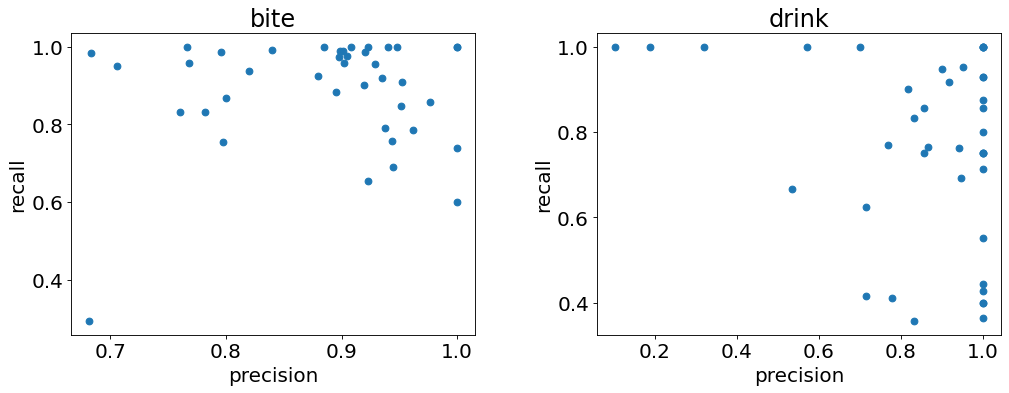

In [9]:
plt.figure(figsize=(15, 5), dpi=80)
plt.subplot(1,2,1)
plt.title("bite",fontsize='large',fontweight='medium')
plt.scatter(bite_precision, bite_recall)
plt.xlabel("precision")
plt.ylabel("recall")

plt.subplot(1,2,2)
plt.title("drink",fontsize='large',fontweight='medium')
plt.scatter(drink_precision, drink_recall)
plt.xlabel("precision")
plt.ylabel("recall")
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=None)
plt.show()

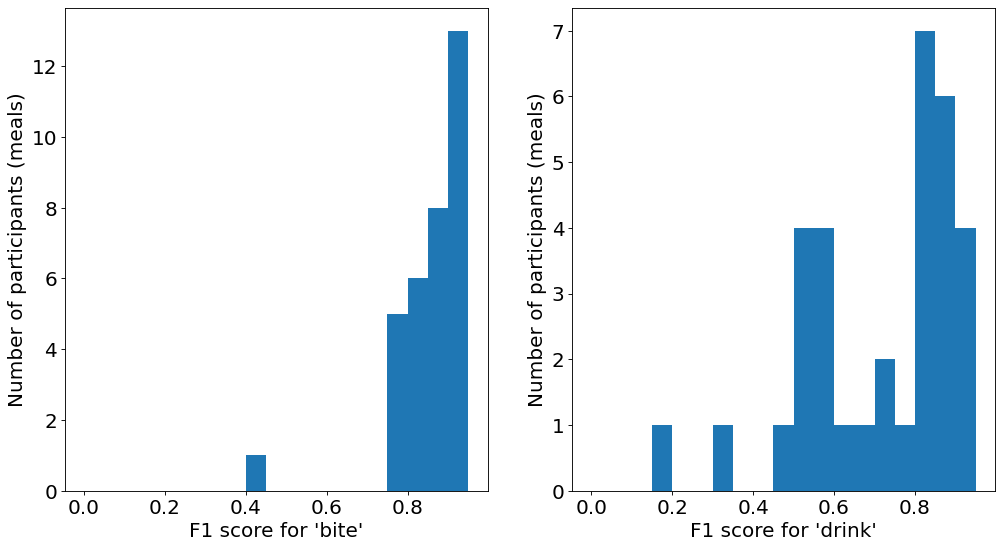

In [12]:
plt.figure(figsize=(15, 8), dpi=80)
plt.subplot(1,2,1)
plt.hist(bite_f1,
         bins=np.arange(0.0,1.0,0.05),
         histtype='bar')
plt.xlabel("F1 score for 'bite'")
plt.ylabel("Number of participants (meals)")

plt.subplot(1,2,2)
plt.hist(drink_f1,
         bins=np.arange(0.0,1.0,0.05),
         histtype='bar')
plt.xlabel("F1 score for 'drink'")
plt.ylabel("Number of participants (meals)")

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.4)
plt.savefig("./histogram.PNG",dpi=1000)
#plt.show()


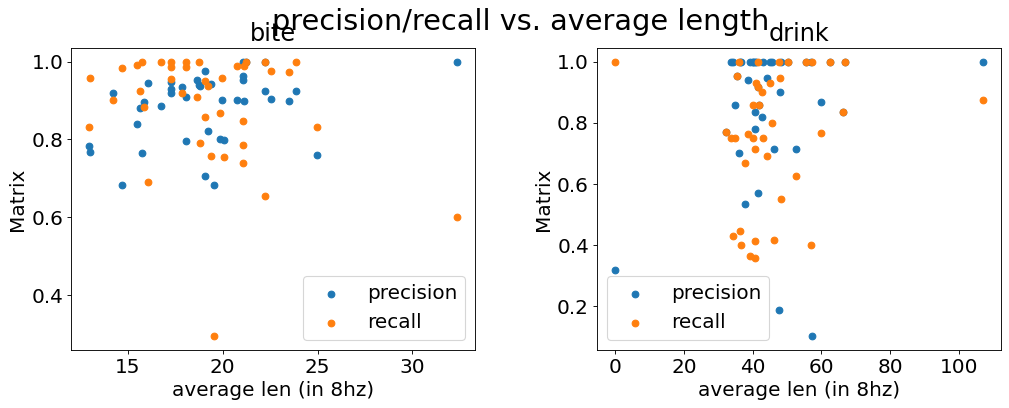

In [44]:
plt.figure(figsize=(15, 5), dpi=80)
plt.suptitle("precision/recall vs. average length",fontsize='x-large',fontweight='medium')
plt.subplot(1,2,1)
plt.title("bite",fontsize='large',fontweight='medium')
plt.scatter(bite_len, bite_precision)
plt.scatter(bite_len, bite_recall)
plt.xlabel("average len (in 8hz)")
plt.ylabel("Matrix")
plt.legend(["precision","recall"])

plt.subplot(1,2,2)
plt.title("drink",fontsize='large',fontweight='medium')
plt.scatter(drink_len, drink_precision)
plt.scatter(drink_len, drink_recall)
plt.xlabel("average len (in 8hz)")
plt.ylabel("Matrix")
plt.legend(["precision","recall"])

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=None)
plt.show()

### Frame-wise result evaluation

In [45]:
result_loc = data_root_dir + f"/reimplementation/results/result_my-lstm-r34_16_8/"

pred_frame_loc = result_loc + "frame_preds/"
video_list = [f[6:-4] for f in os.listdir(pred_frame_loc) if f.startswith("preds")]
frame_matrix = [defaultdict(lambda: defaultdict(lambda: 0)) for _ in range(3)]

total_tp = np.array([0,0,0])
total_p = np.array([0,0,0])
total_detect = np.array([0,0,0])
subject_list = np.array([str.split(video,"_")[0] for video in video_list])
subject_set = sorted(np.unique(subject_list),reverse=False)
#bad_subjects = ['p139','p285','p361']
bad_subjects = []
for video_idx in video_list:
    subject = str.split(video_idx,"_")[0]
    frame_gt = []
    f_pred = open(f"{pred_frame_loc}preds_{video_idx}.txt","r")
    frame_preds = []
    for line in f_pred.readlines():
        info = str.split(str.split(line, "\n")[0], "\t") 
        frame_gt.append(int(info[1]))
        frame_preds.append(int(info[2]))
    frame_preds = np.array(frame_preds)
    frame_gt = np.array(frame_gt)
    f_pred.close()
    cur_uar = 0

    for label in range(3):
        cur_tp = np.logical_and(frame_preds == frame_gt, frame_gt==label).sum()
        cur_p = (frame_gt == label).sum().item()
        cur_detect = (frame_preds == label).sum().item()
        frame_matrix[label][subject]["tp"] += cur_tp
        frame_matrix[label][subject]["p"] += cur_p
        frame_matrix[label][subject]["detect"] += cur_detect
        total_tp[label] += cur_tp
        total_p[label] += cur_p
        total_detect[label] += cur_detect

In [46]:
recall = total_tp/total_p
precision = total_tp/total_detect
f1 = 2 * (recall*precision) / (recall+precision)
frame_uar = np.mean(total_tp/total_p)

print(f"for all frames")
print(f"average uar: {frame_uar}")
print(f"tp: {total_tp}")
print(f"p: {total_p}")
print(f"detection: {total_detect}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"f1 {f1}")

for all frames
average uar: 0.8747281313859233
tp: [ 46365  22672 311284]
p: [ 56354  24652 353027]
detection: [ 73450  37955 322628]
precision: [0.63124575 0.59733895 0.96483876]
recall: [0.8227455  0.91968197 0.88175692]
f1 [0.71438476 0.72426406 0.92142884]


In [47]:
uar_dict = defaultdict(lambda: 0) 
recall_dict = [defaultdict(lambda: 0) for _ in range(3)]
precision_dict = [defaultdict(lambda: 0) for _ in range(3)]
f1_dict = [defaultdict(lambda: 0) for _ in range(3)]
for subject in subject_set:
    for label in range(3):
        recall_dict[label][subject] = frame_matrix[label][subject]["tp"] / frame_matrix[label][subject]["p"]
        precision_dict[label][subject] = frame_matrix[label][subject]["tp"] / frame_matrix[label][subject]["detect"]
        f1_dict[label][subject] = 2 * (recall_dict[label][subject]*precision_dict[label][subject]) / (recall_dict[label][subject]+precision_dict[label][subject])
        uar_dict[subject] += recall_dict[label][subject]
    uar_dict[subject] = uar_dict[subject]/3    
    
recall_list = []
precision_list = []
f1_list = []
uar_list = list(uar_dict.values())
for label in range(3):
    recall_list.append(list(recall_dict[label].values()))
    precision_list.append(list(precision_dict[label].values()))
    f1_list.append(list(f1_dict[label].values()))

In [48]:
print(f"uar: mean: {np.mean(uar_list)}; std: {np.std(uar_list)}")

uar: mean: 0.874519125824731; std: 0.056786624436683975


In [49]:
print(f"for participants")
print(f"recall for bite: mean: {np.mean(recall_list[0])}; std: {np.std(recall_list[0])}")
print(f"recall for drink: mean: {np.mean(recall_list[1])}; std: {np.std(recall_list[1])}")
print(f"recall for non-intake: mean: {np.mean(recall_list[2])}; std: {np.std(recall_list[2])}")
print("------------------------------------------------------------")
print(f"precision for bite: mean: {np.mean(precision_list[0])}; std: {np.std(precision_list[0])}")
print(f"precision for drink: mean: {np.mean(precision_list[1])}; std: {np.std(precision_list[1])}")
print(f"precision for non-intake: mean: {np.mean(precision_list[2])}; std: {np.std(precision_list[2])}")
print("------------------------------------------------------------")
print(f"f1 for bite: mean: {np.mean(f1_list[0])}; std: {np.std(f1_list[0])}")
print(f"f1 for drink: mean: {np.mean(f1_list[1])}; std: {np.std(f1_list[1])}")
print(f"f1 for non-intake: mean: {np.mean(f1_list[2])}; std: {np.std(f1_list[2])}")


for participants
recall for bite: mean: 0.8221999559303441; std: 0.09399065658102883
recall for drink: mean: 0.9231112942174949; std: 0.09958647336663655
recall for non-intake: mean: 0.8782461273263543; std: 0.11957484053415089
------------------------------------------------------------
precision for bite: mean: 0.7041353947734363; std: 0.1645367080218297
precision for drink: mean: 0.6698152343393222; std: 0.21116227303015103
precision for non-intake: mean: 0.9634313408803994; std: 0.02149825477400638
------------------------------------------------------------
f1 for bite: mean: 0.7384928298083053; std: 0.09040323289483107
f1 for drink: mean: 0.7523703510151776; std: 0.18302893577641796
f1 for non-intake: mean: 0.9136136670397066; std: 0.08232938854485142


### Count the difference between orginal and augmented gt

In [44]:
gt_loc = "/scratch1/zeyut/eat_detection/all_labels/"
video_list = [f for f in os.listdir(gt_loc)]
bite_count = 0
drink_count = 0

for video_idx in video_list:
    subject = video_idx
    #subject = str.split(video_idx,"_")[0]
    f_gt = open(f"{gt_loc}{video_idx}/gt_ges_3labels.txt","r")
    for line in f_gt.readlines():
        info = str.split(str.split(line, "\n")[0], "\t") 
        if info[0] == "bite":
            bite_count += 1
        if info[0] == "drink":
            drink_count += 1 
print(f"drink: {drink_count}")
print(f"bite: {bite_count}")

drink: 3510
bite: 19632


### Gesture count results

In [304]:
video_idx = 625
offset = 910
(video_idx/8*1000-offset)/1000*15

1158.2250000000001

In [31]:
620 * 1000 / 8

77500.0

In [32]:
(77500.0 - 7312 ) * 15 /1000

1052.82

In [305]:
sensor_idx = 841
(sensor_idx/15*1000+offset)/1000*8

455.8133333333334

bad videos on 'bite':
p086,p324

bad videos on 'drink':
p059,p139,p190,p265,p285,p292

bad videos on 'uar':
p139,p285,p361,p015,p086,p279,p291,p270,p060,p217

### Convert seq2seq test results to seq2one results

In [1]:
import sys
import os
import numpy as np

In [9]:
model_idx = 1
result_loc = f"/scratch1/zeyut/eat_detection/results/{model_idx}/result_RES_BILSTM_50_16_8_v4_test/"
prob_loc = result_loc + "frame_probs/"
save_loc = os.path.join(result_loc,'frame_preds_seq2one')
filelist = [f for f in os.listdir(prob_loc) if f.startswith('probs')]
seq_len = 16
try:
    os.mkdir(save_loc)
except:
    pass      


In [3]:
sys.path.append("../src/")
from utils import testDataset


In [4]:
test_set = testDataset(
                    data_path=f"/scratch1/zeyut/eat_detection/VideoData_independent_8hz/test_set/p072_c1/",
                    seq_len=seq_len,
                    stride=1,
                    transform=None
                    )

In [5]:
len(test_set.frame_names)

7044

In [11]:
for file in ["probs_p029_c1.txt"]:
    f_probs = open(os.path.join(prob_loc,file),'r')
    video_name = file[6:13]
    frame_names = []
    video_labels = []
    pred_list = []
    
    f_preds = open(os.path.join(result_loc,"frame_preds",f"preds_{video_name}.txt"),'r')
    content1 = f_preds.readlines()
    for line in content1:
        frame_names.append(line.split("\t")[0])
        video_labels.append(line.split("\t")[1])
    f_preds.close()
    content2 = f_probs.readlines()
    for line in content2:
        # frame's indexes start from 0. This is to align the convention of visualization
        cur_probs = line.split("\n")[0].split("\t")[-3:]
        cur_probs = np.array(list(map(float,cur_probs)))
        pred_list.append(cur_probs.argmax(-1))
    f_probs.close()
    
    video_preds = np.zeros(len(frame_names))
    video_preds[seq_len-1:seq_len-1+len(pred_list)] = pred_list      
    
    f_results = open(os.path.join(save_loc, file),'w')
    f_results.write("\n".join(["{}\t{}\t{}".format(i,j,int(k)) for i,j,k in (zip(frame_names,video_labels,video_preds))]))
    f_results.close()  

    

In [15]:
len(frame_names)

9394

In [58]:
content2[-1]

'7040\t0.000074\t0.000035\t0.999891\t0.000014\t0.000008\t0.999978\t0.000009\t0.000005\t0.999985\t0.000007\t0.000004\t0.999989\t0.000007\t0.000004\t0.999988\t0.000007\t0.000005\t0.999988\t0.000006\t0.000005\t0.999989\t0.000006\t0.000005\t0.999989\t0.000005\t0.000005\t0.999990\t0.000006\t0.000006\t0.999987\t0.000007\t0.000008\t0.999985\t0.000007\t0.000007\t0.999986\t0.000008\t0.000010\t0.999982\t0.000009\t0.000010\t0.999981\t0.000006\t0.000006\t0.999988\t0.000004\t0.000004\t0.999992\n'

In [64]:
gt[-1]

'frame_007056.ppm\tnon_intake\n'

In [63]:
f = open(f"/scratch1/zeyut/eat_detection/VideoData_independent_8hz/test_set/p072_c1/gt_frame_3labels.txt")
gt = f.readlines()

In [38]:
f_probs = open(os.path.join(prob_loc,file),'r')
line = f_probs.readlines()[0]
cur_probs = line.split("\n")[0].split("\t")[-3:]
print(cur_probs)
cur_probs = np.array(list(map(float,cur_probs)))

['0.000009', '0.000009', '0.999982']


In [53]:
a = [1,2,3,4,5]
b = [6,7,8]
for i,j in zip(a,b):
    print(i,j)

1 6
2 7
3 8
